In [12]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
import PIL
import random
import seaborn as sns
from pathlib import Path
import cv2


In [13]:
# Set random seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed}")

set_seed(42)

# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define paths
DATA_ROOT = r"D:\Uni\Lab\inebriation-voice-detector\data\processed"
TRAIN_DIR = os.path.join(DATA_ROOT, "TRAIN")
VAL_DIR = os.path.join(DATA_ROOT, "VALIDATION")
TEST_DIR = os.path.join(DATA_ROOT, "TEST")

# Create output directory
OUTPUT_ROOT = r"D:\Uni\Lab\inebriation-voice-detector\output"
OUTPUT_DIR =os.path.join(OUTPUT_ROOT, "simpleCNN")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Define class labels
classes = ['SOBER', 'DRUNK']
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for idx, cls in enumerate(classes)}


Random seed set to 42
Using device: cuda:0


## Data Exploration

In [14]:


def explore_dataset(data_dir, title):
    """Explore the dataset and visualize class distribution."""
    class_counts = {cls: 0 for cls in classes}
    file_paths = []
    labels = []
    
    for class_name in classes:
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png'))]
            class_counts[class_name] = len(files)
            
            for file in files:
                file_paths.append(os.path.join(class_path, file))
                labels.append(class_to_idx[class_name])
    
    # Print statistics
    print(f"\n{title} Dataset Statistics:")
    for cls, count in class_counts.items():
        print(f"  {cls}: {count} samples")
    print(f"  Total: {sum(class_counts.values())} samples")
    
    # Plot class distribution
    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
    plt.title(f"{title} Dataset Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Number of Samples")
    for i, count in enumerate(class_counts.values()):
        plt.text(i, count + 5, str(count), ha='center')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{title.lower()}_class_distribution.png"))
    plt.close()
    
    return file_paths, labels, class_counts

# Explore all datasets
train_files, train_labels, train_counts = explore_dataset(TRAIN_DIR, "Training")
val_files, val_labels, val_counts = explore_dataset(VAL_DIR, "Validation")
test_files, test_labels, test_counts = explore_dataset(TEST_DIR, "Test")


Training Dataset Statistics:
  SOBER: 5189 samples
  DRUNK: 2281 samples
  Total: 7470 samples

Validation Dataset Statistics:
  SOBER: 3741 samples
  DRUNK: 1573 samples
  Total: 5314 samples

Test Dataset Statistics:
  SOBER: 2187 samples
  DRUNK: 1858 samples
  Total: 4045 samples


## Data Visualization

In [15]:


def visualize_spectrograms(file_paths, labels, num_samples=5, save_path=None):
    """Visualize sample spectrograms from each class"""
    # Get sample images from each class
    samples_by_class = {cls: [] for cls in classes}
    for path, label in zip(file_paths, labels):
        class_name = idx_to_class[label]
        if len(samples_by_class[class_name]) < num_samples:
            samples_by_class[class_name].append(path)
    
    # Create subplot grid
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(15, 5))
    
    for i, class_name in enumerate(classes):
        for j, img_path in enumerate(samples_by_class[class_name]):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{class_name}")
            axes[i, j].axis('off')
    
    plt.suptitle("Sample Spectrogram Images")
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    plt.close()

# Visualize sample spectrograms
visualize_spectrograms(
    train_files, 
    train_labels, 
    num_samples=5, 
    save_path=os.path.join(OUTPUT_DIR, "sample_spectrograms.png")
)

## Dataset 

In [16]:

class SpectrogramDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['SOBER', 'DRUNK']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.samples = self._make_dataset()
        
    def _make_dataset(self):
        samples = []
        for class_name in os.listdir(self.root_dir):
            class_path = os.path.join(self.root_dir, class_name)
            if os.path.isdir(class_path):
                class_idx = self.class_to_idx[class_name]
                for filename in os.listdir(class_path):
                    if filename.endswith(('.jpg', '.jpeg', '.png')):
                        samples.append((
                            os.path.join(class_path, filename),
                            class_idx
                        ))
        return samples
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label



## Data Preparation

In [17]:

# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Initialize datasets

train_dataset = SpectrogramDataset(TRAIN_DIR, transform)
val_dataset = SpectrogramDataset(VAL_DIR, transform)
test_dataset = SpectrogramDataset(TEST_DIR, transform)

# Create balanced sampler
class_counts = torch.tensor([len([x for x in train_dataset.samples if x[1] == i]) for i in range(2)])
class_weights = 1. / class_counts
class_weights = class_weights / class_weights.sum()  # Normalize
sample_weights = torch.tensor([class_weights[y] for _, y in train_dataset.samples])
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# Create data loaders
BATCH_SIZE = 100
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Model

In [18]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # Input: RGB (3, 224, 224)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # -> (32, 112, 112)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # -> (64, 56, 56)

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # -> (128, 28, 28)

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))  # -> (256, 1, 1)
        )
        
        self.classifier = nn.Linear(256, 1)  # Binary output

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)  # Logits (use with BCEWithLogitsLoss)


def simplecnn_classifier():
    model = SimpleCNN()
    return model.to(device)


## Training Set Up

In [ ]:

#model = resnet18_classifier()
model = simplecnn_classifier()
initial_lr = .001  # Start with a very small lr
patience = 10  # Early stopping patience
num_epochs = 30

# Use class distribution from training data to set pos_weight
# train_counts = {'SOBER': 5189, 'DRUNK': 2281}
pos_weight = torch.tensor([train_counts['SOBER'] / train_counts['DRUNK']]).to(device)

# Use BCEWithLogitsLoss with pos_weight to handle imbalance
#criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
criterion = nn.BCEWithLogitsLoss()

# Optimizer for fine-tuned layers only
# optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, weight_decay=1e-4)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=initial_lr , weight_decay=1e-4)
#optimizer = optim.Adam(model.parameters(), lr=initial_lr )

# Learning rate scheduler — Reduce on plateau (e.g., validation loss)
#scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=patience, factor=0.5)


print("\nTraining setup:")
print("Model: simplecnn_classifier")
print("Optimizer: Adam(lr=0.001, weight_decay=1e-4)")
print("LR scheduler: ReduceLROnPlateau (on val loss)")
print(f"Using pos_weight = {pos_weight.item():.4f}")


Training setup:
Model: simplecnn_classifier
Optimizer: Adam(lr=0.001, weight_decay=1e-4)
LR scheduler: ReduceLROnPlateau (on val loss)
Using pos_weight = 2.2749


In [20]:


# Evaluation Function
def evaluate(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    running_loss = 0.0
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).float()
            
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            preds = (outputs >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Calculate UAR (Unweighted Average Recall)
    cm = confusion_matrix(all_labels, all_preds)
    if cm.shape == (2, 2):  # binary classification
        tn, fp, fn, tp = cm.ravel()
        tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        uar = (tpr + tnr) / 2
    else:  # handle case when one class is missing in predictions
        uar = accuracy_score(all_labels, all_preds)  # fallback
    
    metrics = {
        'loss': running_loss / len(data_loader.dataset),
        'accuracy': accuracy_score(all_labels, all_preds),
        'uar': uar,
        'confusion_matrix': cm
    }
    
    return metrics

## Training


Epoch 1/30
----------


Training: 100%|██████████| 75/75 [00:20<00:00,  3.68it/s]


Train Loss: 0.9397 | Val Loss: 1.0835
Train Acc: 0.6870 | Val Acc: 0.4484
Train UAR: 0.5262 | Val UAR: 0.5327
Validation Confusion Matrix:
[[1220 2521]
 [ 410 1163]]
Saved new best model (based on UAR)!

Epoch 2/30
----------


Training: 100%|██████████| 75/75 [00:19<00:00,  3.83it/s]


Train Loss: 0.9263 | Val Loss: 1.1734
Train Acc: 0.6937 | Val Acc: 0.4232
Train UAR: 0.5498 | Val UAR: 0.5272
Validation Confusion Matrix:
[[1019 2722]
 [ 343 1230]]
No improvement in UAR for 1/10 epochs

Epoch 3/30
----------


...

Train Loss: 0.7125 | Val Loss: 1.5644
Train Acc: 0.7780 | Val Acc: 0.4125
Train UAR: 0.7229 | Val UAR: 0.5498
Validation Confusion Matrix:
[[ 798 2943]
 [ 179 1394]]
No improvement in UAR for 8/10 epochs

Epoch 27/30
----------


Training: 100%|██████████| 75/75 [00:19<00:00,  3.82it/s]


Train Loss: 0.6897 | Val Loss: 2.2428
Train Acc: 0.7937 | Val Acc: 0.3568
Train UAR: 0.7416 | Val UAR: 0.5271
Validation Confusion Matrix:
[[ 410 3331]
 [  87 1486]]
No improvement in UAR for 9/10 epochs

Epoch 28/30
----------


Training: 100%|██████████| 75/75 [00:19<00:00,  3.84it/s]


Train Loss: 0.6833 | Val Loss: 1.5388
Train Acc: 0.7898 | Val Acc: 0.7072
Train UAR: 0.7361 | Val UAR: 0.5131
Validation Confusion Matrix:
[[3699   42]
 [1514   59]]
No improvement in UAR for 10/10 epochs

Early stopping triggered after 10 epochs without improvement!

Training completed. Loaded best model weights.


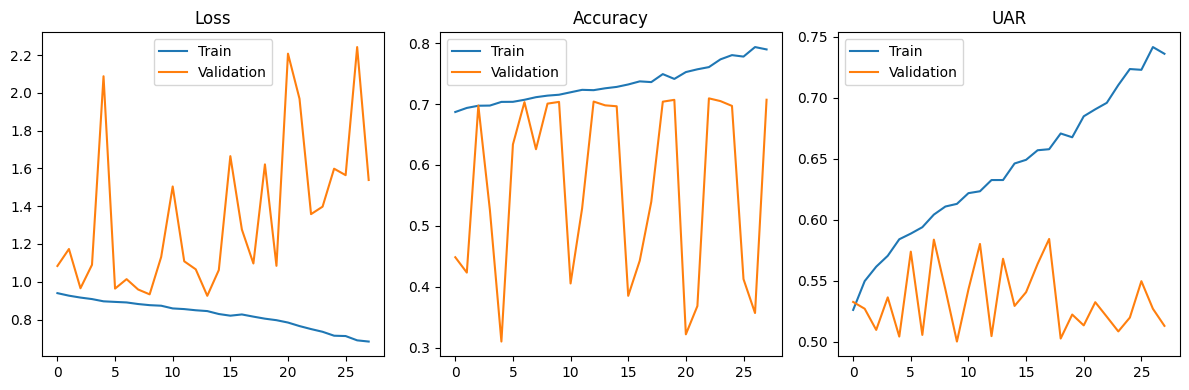


Final Test Results:
Accuracy: 0.5646
UAR: 0.5793
Confusion Matrix:
[[ 873 1314]
 [ 447 1411]]


In [21]:
# Training Loop with Early Stopping
def train_model(model, train_loader, val_loader, num_epochs, patience):
    best_uar = 0
    no_improvement = 0
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_uar': [], 'val_uar': []
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 10)
        
        # Training phase
        model.train()
        train_loss = 0
        train_preds = []
        train_labels = []
        
        for inputs, labels in tqdm(train_loader, desc="Training"):
            inputs, labels = inputs.to(device), labels.to(device).float()
            
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            preds = (outputs >= 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        
        # Calculate training metrics
        train_loss = train_loss / len(train_loader.dataset)
        train_acc = accuracy_score(train_labels, train_preds)
        
        # Calculate training UAR
        train_cm = confusion_matrix(train_labels, train_preds)
        if train_cm.shape == (2, 2):
            tn, fp, fn, tp = train_cm.ravel()
            tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
            tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
            train_uar = (tpr + tnr) / 2
        else:
            train_uar = train_acc
        
        # Validation phase
        val_metrics = evaluate(model, val_loader)
        
        # Update LR scheduler
        # scheduler.step()
        #scheduler.step(val_metrics['loss'])
        
        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_metrics['accuracy'])
        history['train_uar'].append(train_uar)
        history['val_uar'].append(val_metrics['uar'])
        
        # Print metrics
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f}")
        print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_metrics['accuracy']:.4f}")
        print(f"Train UAR: {train_uar:.4f} | Val UAR: {val_metrics['uar']:.4f}")
        print("Validation Confusion Matrix:")
        print(val_metrics['confusion_matrix'])
        
        # Early stopping check
        if val_metrics['uar'] > best_uar:
            best_uar = val_metrics['uar']
            no_improvement = 0
            torch.save(model.state_dict(), os.path.join(OUTPUT_DIR,"best_model.pth"))
            print("Saved new best model (based on UAR)!")
        else:
            no_improvement += 1
            print(f"No improvement in UAR for {no_improvement}/{patience} epochs")
            
            if no_improvement >= patience:
                print(f"\nEarly stopping triggered after {patience} epochs without improvement!")
                break
    
    # Load the best model weights before returning
    model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR,"best_model.pth")) )
    print("\nTraining completed. Loaded best model weights.")
    
    return history

# Train the model with early stopping
history = train_model(
    model, 
    train_loader, 
    val_loader, 
    num_epochs,
    patience  # Stop if no improvement for 10 epochs
)


# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history['train_acc'], label='Train')
plt.plot(history['val_acc'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history['train_uar'], label='Train')
plt.plot(history['val_uar'], label='Validation')
plt.title('UAR')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"training_curves.png"))
plt.show()


# Load best model and evaluate on test set
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR,"best_model.pth")) )
test_metrics = evaluate(model, test_loader)

print("\nFinal Test Results:")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"UAR: {test_metrics['uar']:.4f}")
print("Confusion Matrix:")
print(test_metrics['confusion_matrix'])

## Evaluation


Final Test Results:
Loss: 1.0361
Accuracy: 0.5646
UAR: 0.5793
Confusion Matrix:
[[ 873 1314]
 [ 447 1411]]


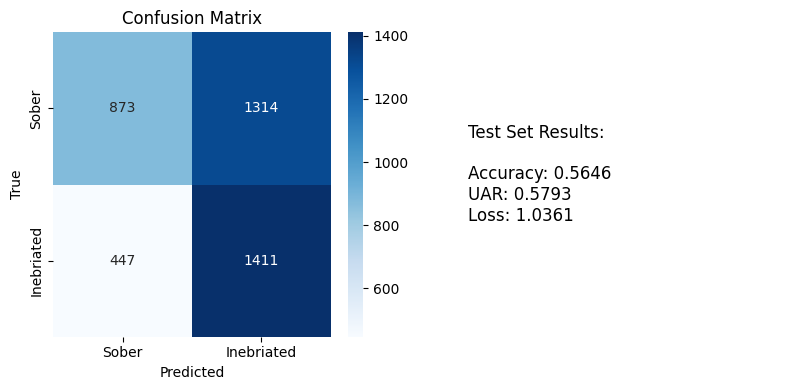

In [22]:
def plot_results(metrics, class_names):
    plt.figure(figsize=(8, 4))
    
    # Confusion matrix
    plt.subplot(1, 2, 1)
    sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', 
                cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    
    # Metrics summary
    plt.subplot(1, 2, 2)
    plt.axis('off')
    metrics_text = (
        "Test Set Results:\n\n"
        f"Accuracy: {metrics['accuracy']:.4f}\n"
        f"UAR: {metrics['uar']:.4f}\n"
        f"Loss: {metrics['loss']:.4f}\n"
    )
    plt.text(0.1, 0.5, metrics_text, fontsize=12, va='center')
    
    plt.tight_layout()
    plt.savefig("output/test_results.png")
    plt.show()

# Load best model and evaluate
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR,"best_model.pth")))
test_metrics = evaluate(model, test_loader)

print("\nFinal Test Results:")
print(f"Loss: {test_metrics['loss']:.4f}")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"UAR: {test_metrics['uar']:.4f}")
print("Confusion Matrix:")
print(test_metrics['confusion_matrix'])

# Plot results
plot_results(test_metrics, ['Sober', 'Inebriated'])  # Replace with your actual class names
